# Setup

In [359]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from nds_toolbox.preprocessing.features import compute_wavelet

import seaborn as sns




In [360]:

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9


plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,


    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


# 2-state scenario

In [3]:
sim_cond = "2states"
signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond}_data.npz', allow_pickle=True)

#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']

print("shape of signal_sample", signal_sample.shape)


performance_dir = "../data/performance"
file_path = f"{performance_dir}/{sim_cond}_results.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)
df.head()


shape of signal_sample (5, 5, 3)


,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 1.1864136, 'weights': [0.5664814, 0....",1.0383563,3.0,1.294949e+09,...,0.703789,42.630307,2,3,"[0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, ...","[1, 0]",None,0.335422,1.0383563,NaN
1,HMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'initial_probs': [0.30523705, 0.69476295], 't...",0.966394,NaN,NaN,...,0.222408,25.507082,2,3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0]",None,0.361506,0.966394,6.0
2,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 1.3546937, 'weights': [0.5758428, 0....",0.920575,6.0,3.662778e+09,...,0.485350,45.494302,2,7,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...","[1, 0]",None,0.621023,0.920575,NaN
3,HMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'initial_probs': [0.84225214, 0.1577479], 'tr...",0.858959,NaN,NaN,...,0.135526,20.768653,2,7,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...","[1, 0]",None,0.783673,0.858959,0.0
4,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.7397532, 'weights': [0.6435321, 0....",0.87031615,1.0,1.065091e+08,...,0.457351,49.514931,2,11,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.746127,0.87031615,NaN


In [4]:
median_df = pd.DataFrame(df.groupby(["method", "burst_f", "fs", "num_emb"]).mcc.agg(median_mcc = "median")).reset_index()
median_df["window_size"] = 1/ median_df["fs"].values * median_df["num_emb"].values

print(median_df.shape)
median_df.head()

(390, 6)


,method,burst_f,fs,num_emb,median_mcc,window_size
0,DP-GMM,10,100,3,0.229899,0.03
1,DP-GMM,10,100,7,0.609460,0.07
2,DP-GMM,10,100,11,0.725375,0.11
3,DP-GMM,10,100,15,0.786066,0.15
4,DP-GMM,10,100,19,0.826460,0.19


In [5]:


palette = sns.color_palette("viridis", n_colors=median_df['num_emb'].nunique())

print(palette)
print(median_df["num_emb"].unique())

[(0.28291, 0.105393, 0.426902), (0.275191, 0.194905, 0.496005), (0.248629, 0.278775, 0.534556), (0.212395, 0.359683, 0.55171), (0.180629, 0.429975, 0.557282), (0.153364, 0.497, 0.557724), (0.127568, 0.566949, 0.550556), (0.122312, 0.633153, 0.530398), (0.175707, 0.6979, 0.491033), (0.288921, 0.758394, 0.428426), (0.449368, 0.813768, 0.335384), (0.626579, 0.854645, 0.223353), (0.814576, 0.883393, 0.110347)]
[ 3  7 11 15 19 23 27 31 35 39 43 47 51]


2states


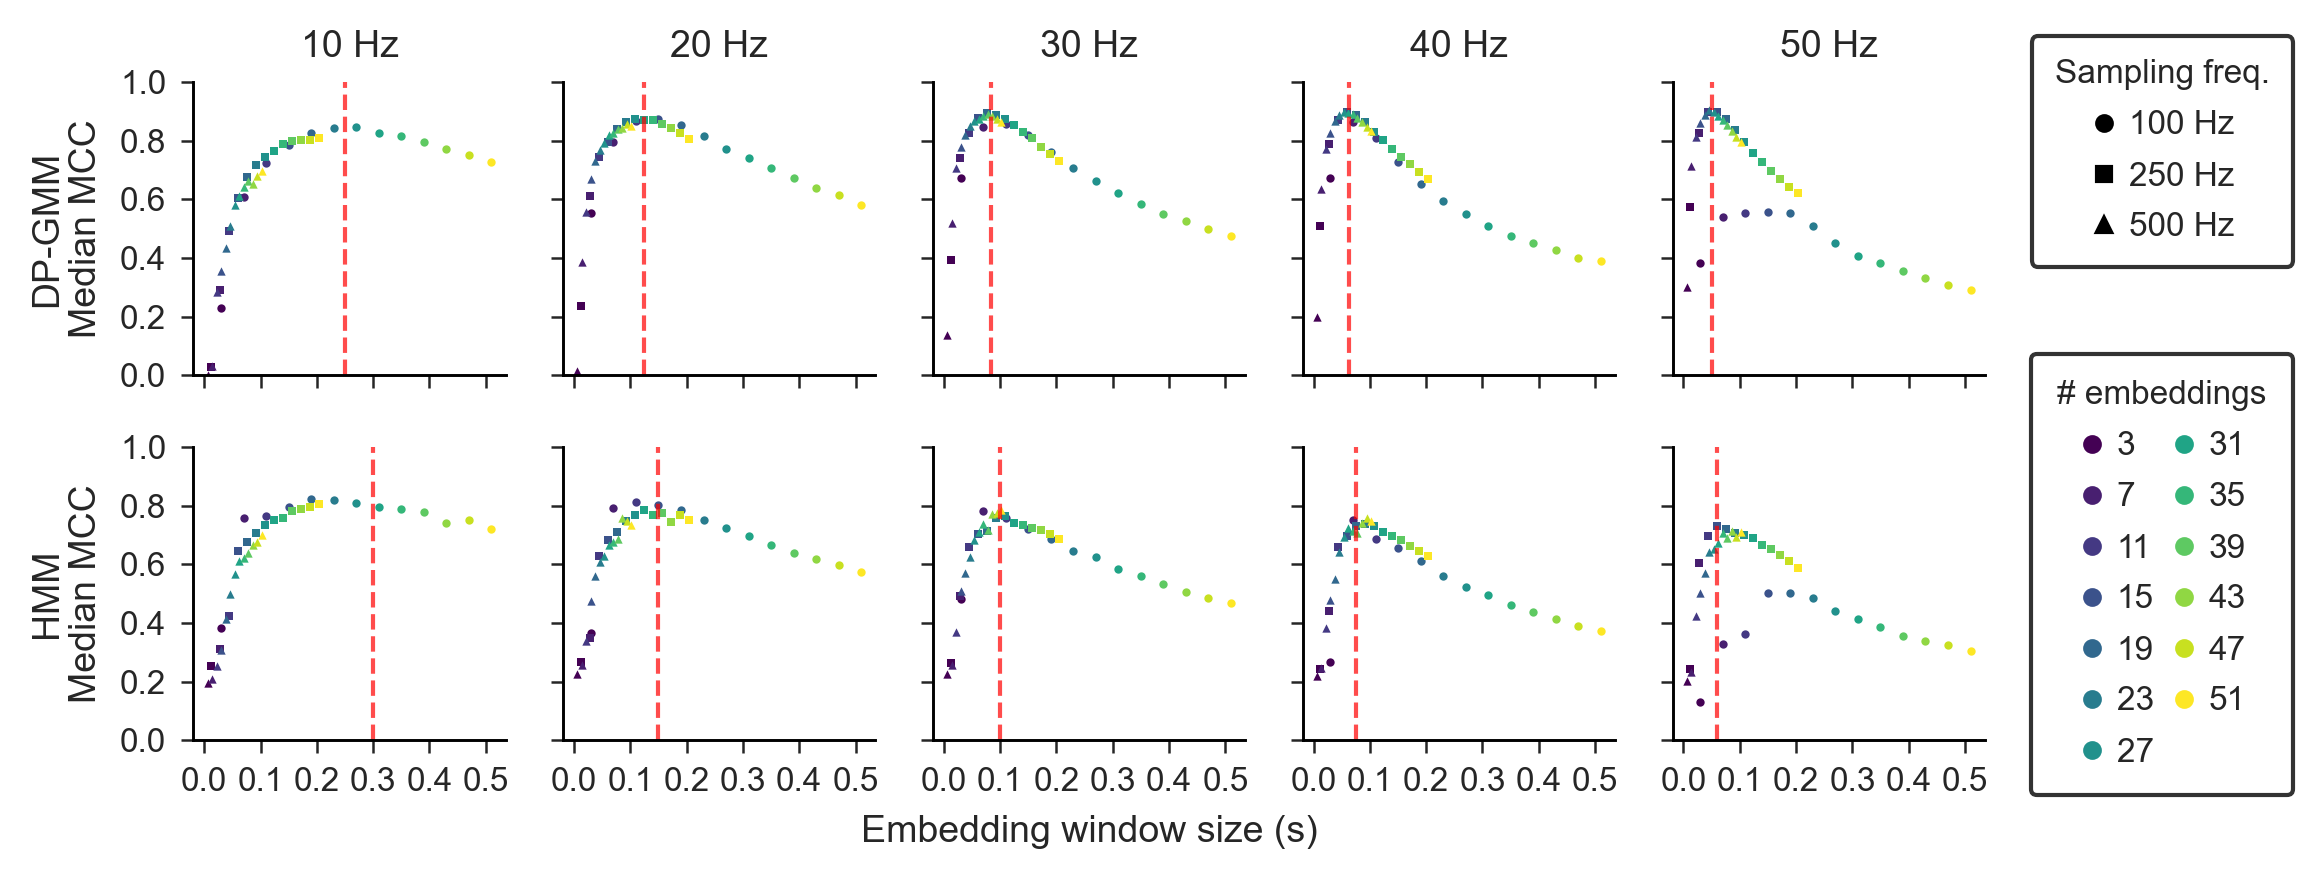

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

# =========================
# CONFIG
# =========================
CYCLES = {
    "DP-GMM": 2.5,
    "HMM": 3,
}

SCATTER_SIZE = 4            # points in panels
LEG_FSIZE = 8
TITLE_FSIZE = 8
LEG_MARKERSIZE = 3.5        # marker size inside legends
RIGHT_MARGIN = 0.8         # reserve space for legends (tune 0.78–0.86)
ANCHOR_X = 0.91             # legend x position (keep near 1.0 to avoid wide save)

# =========================
# STABLE ORDERING
# =========================
methods   = list(median_df["method"].dropna().unique())
burst_fs  = np.sort(median_df["burst_f"].dropna().unique())
num_embs  = np.sort(median_df["num_emb"].dropna().unique())
fs_levels = np.sort(median_df["fs"].dropna().unique())

# =========================
# COLOR PALETTE (num_emb)
# =========================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================
# MARKER MAP (fs)
# =========================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]

marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(methods), len(burst_fs),
    figsize=(FIG_WIDTH+1, 3),   # you control FIG_WIDTH externally
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# =========================
# PLOTTING
# =========================
for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]
        sub_df = median_df[(median_df["method"] == method) & (median_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(0.2))
        ax.xaxis.set_major_locator(MultipleLocator(0.1))
        ax.tick_params(axis="both", which="major", labelsize=8)
        ax.set_ylim(0, 1)

        # reference: TRUTH_CYCLES cycles of the simulated burst frequency
        ax.axvline(
            x=CYCLES[str(method)] / bf,
            color="red",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7
        )

        # color encodes num_emb, shape encodes fs
        for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
            ax.scatter(
                g["window_size"], g["median_mcc"],
                color=palette[emb],
                marker=marker_map[fs],
                s=SCATTER_SIZE,
                linewidths=0
            )

        if i == 0:
            ax.set_title(f"{bf:g} Hz")
        if j == 0:
            ax.set_ylabel(f"{method}\nMedian MCC")

# x-label: bottom row, middle column
axes[-1, len(burst_fs)//2].set_xlabel("Embedding window size (s)")

# =========================
# LAYOUT: reserve legend strip on the right
# =========================
fig.subplots_adjust(right=RIGHT_MARGIN)
plt.tight_layout(rect=[0, 0, RIGHT_MARGIN, 1])

# =========================
# LEGENDS (your version)
# =========================
emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg1 = fig.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.35),
    ncol=2,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.8,
    labelspacing=0.60,
    handletextpad=0.35,
    columnspacing=0.50,
    handlelength=0.8
)
leg1.get_frame().set_edgecolor("black")

fs_handles = [
    mlines.Line2D(
        [], [], color="black", marker=marker_map[fs], linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg2 = fig.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.82),
    ncol=1,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.7,
    labelspacing=0.60,
    handletextpad=0.35,
    handlelength=0.8
)
leg2.get_frame().set_edgecolor("black")


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.svg",
    bbox_inches="tight",
)

fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.pdf",
    bbox_inches="tight",
)



print(sim_cond)

plt.show()


# 3-state scenario

In [233]:
from nds_toolbox.preprocessing.features import choose_embedding_dim, trim_data


fs = 250         # Sampling frequency in Hz.
n_seconds = 60*3   # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))


# Condition 1: frequency distances (3 states)
freqs_dist_range = [[10, 40], [15, 40], [20, 40], [25, 40], [30, 40],[35, 40]]  #30, 25, 20, 15, 10, 5Hz diff

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB




In [275]:


# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB


sim_cond = "3states"
signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond}_data.npz')


#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']
bursts_sample = sim_data['bursts_sample']

print("shape of signal_sample", signal_sample.shape)

shape of signal_sample (5, 6, 11, 45000)


In [276]:

performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df_3states = pd.concat(df_list, axis = 0, ignore_index = True)

df_3states["burst_f"] = df_3states["burst_f"].apply(tuple)

df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.41928005, 'weights': [0.9912948, 0...",0.7935155,1.0,454024514.0,...,0.584623,64.847692,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 1]",None,0.008292,0.7935155,NaN
1,DP-GMM (Imputed),"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.41928005, 'weights': [0.9912948, 0...",0.7935155,1.0,454024514.0,...,0.584623,64.847692,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.000000,0.7935155,NaN
2,HMM,"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'initial_probs': [0.2749775, 0.2459743, 0.479...",0.756271,NaN,NaN,...,0.124677,228.905468,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 0, 1]",None,0.082278,0.756271,17.0
3,HMM (Imputed),"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'initial_probs': [0.2749775, 0.2459743, 0.479...",0.756271,NaN,NaN,...,0.124677,228.905468,3,31,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 0, 1]",None,0.081997,0.756271,17.0
4,Thresholding,"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'enveloped_signal': [[0.2378341, 0.23366168, ...",NaN,NaN,NaN,...,0.001473,1.567317,3,1,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.255669,"[[0.4, 0.30000000000000004], [0.5, 0.5]]",NaN


In [279]:
num_states = 3
snr_db = 0
snr_id = np.where(snr_range == snr_db)[0][0]
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 0

res = df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]
hmm_res = res.query("method == 'HMM (Imputed)'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding (Imputed)'").iloc[sample_id]







hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

#note HMM uses more embeddings: -> align with hmm state length later
num_emb_hmm = int(hmm_res.num_emb)


#crop true states
trimmed_signal = trim_data(signal_sample[sample_id, freq_id, snr_id], num_emb_hmm)
trimmed_states = trim_data(states_sample[sample_id, freq_id, snr_id], num_emb_hmm).astype(int)
trimmed_bursts = trim_data(bursts_sample[sample_id, freq_id, snr_id], num_emb_hmm)
trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
states_onehot = np.eye(num_states)[trimmed_states]




dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
num_emb_dpgmm = dpgmm_res.num_emb








#crop threshold length
thresh_states = thresh_res.est_states
thresh_states = trim_data(thresh_states, num_emb_hmm)


thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]





Lost 12 data points were lost from both ends.
data shape: (44976,)
Lost 12 data points were lost from both ends.
data shape: (44976,)
Lost 12 data points were lost from both ends.
data shape: (44976,)
Lost 12 data points were lost from both ends.
data shape: (44976,)


In [280]:
print(trimmed_states.shape)
print(dpgmm_states_onehot.shape)
print(hmm_states_onehot.shape)
print(thresh_states_onehot.shape)

(44976,)
(44976, 3)
(44976, 3)
(44976, 3)


In [281]:
df_median = (
    df_3states
    .query("burst_f == @plot_f")
    .groupby(["method", "snr"], as_index=False)
    .agg(
        mcc_median=("mcc", "median"),
        mcc_q25=("mcc", lambda x: x.quantile(0.25)),
        mcc_q75=("mcc", lambda x: x.quantile(0.75)),
    )
)

In [282]:
def relabel_freqs(burst_f):
    f0, f1 = burst_f 
    label = f"{str(f0)}&{str(f1)}"
    return label


df_3states["burst_f"] = df_3states["burst_f"].apply(relabel_freqs)


/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_3244/2467281283.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


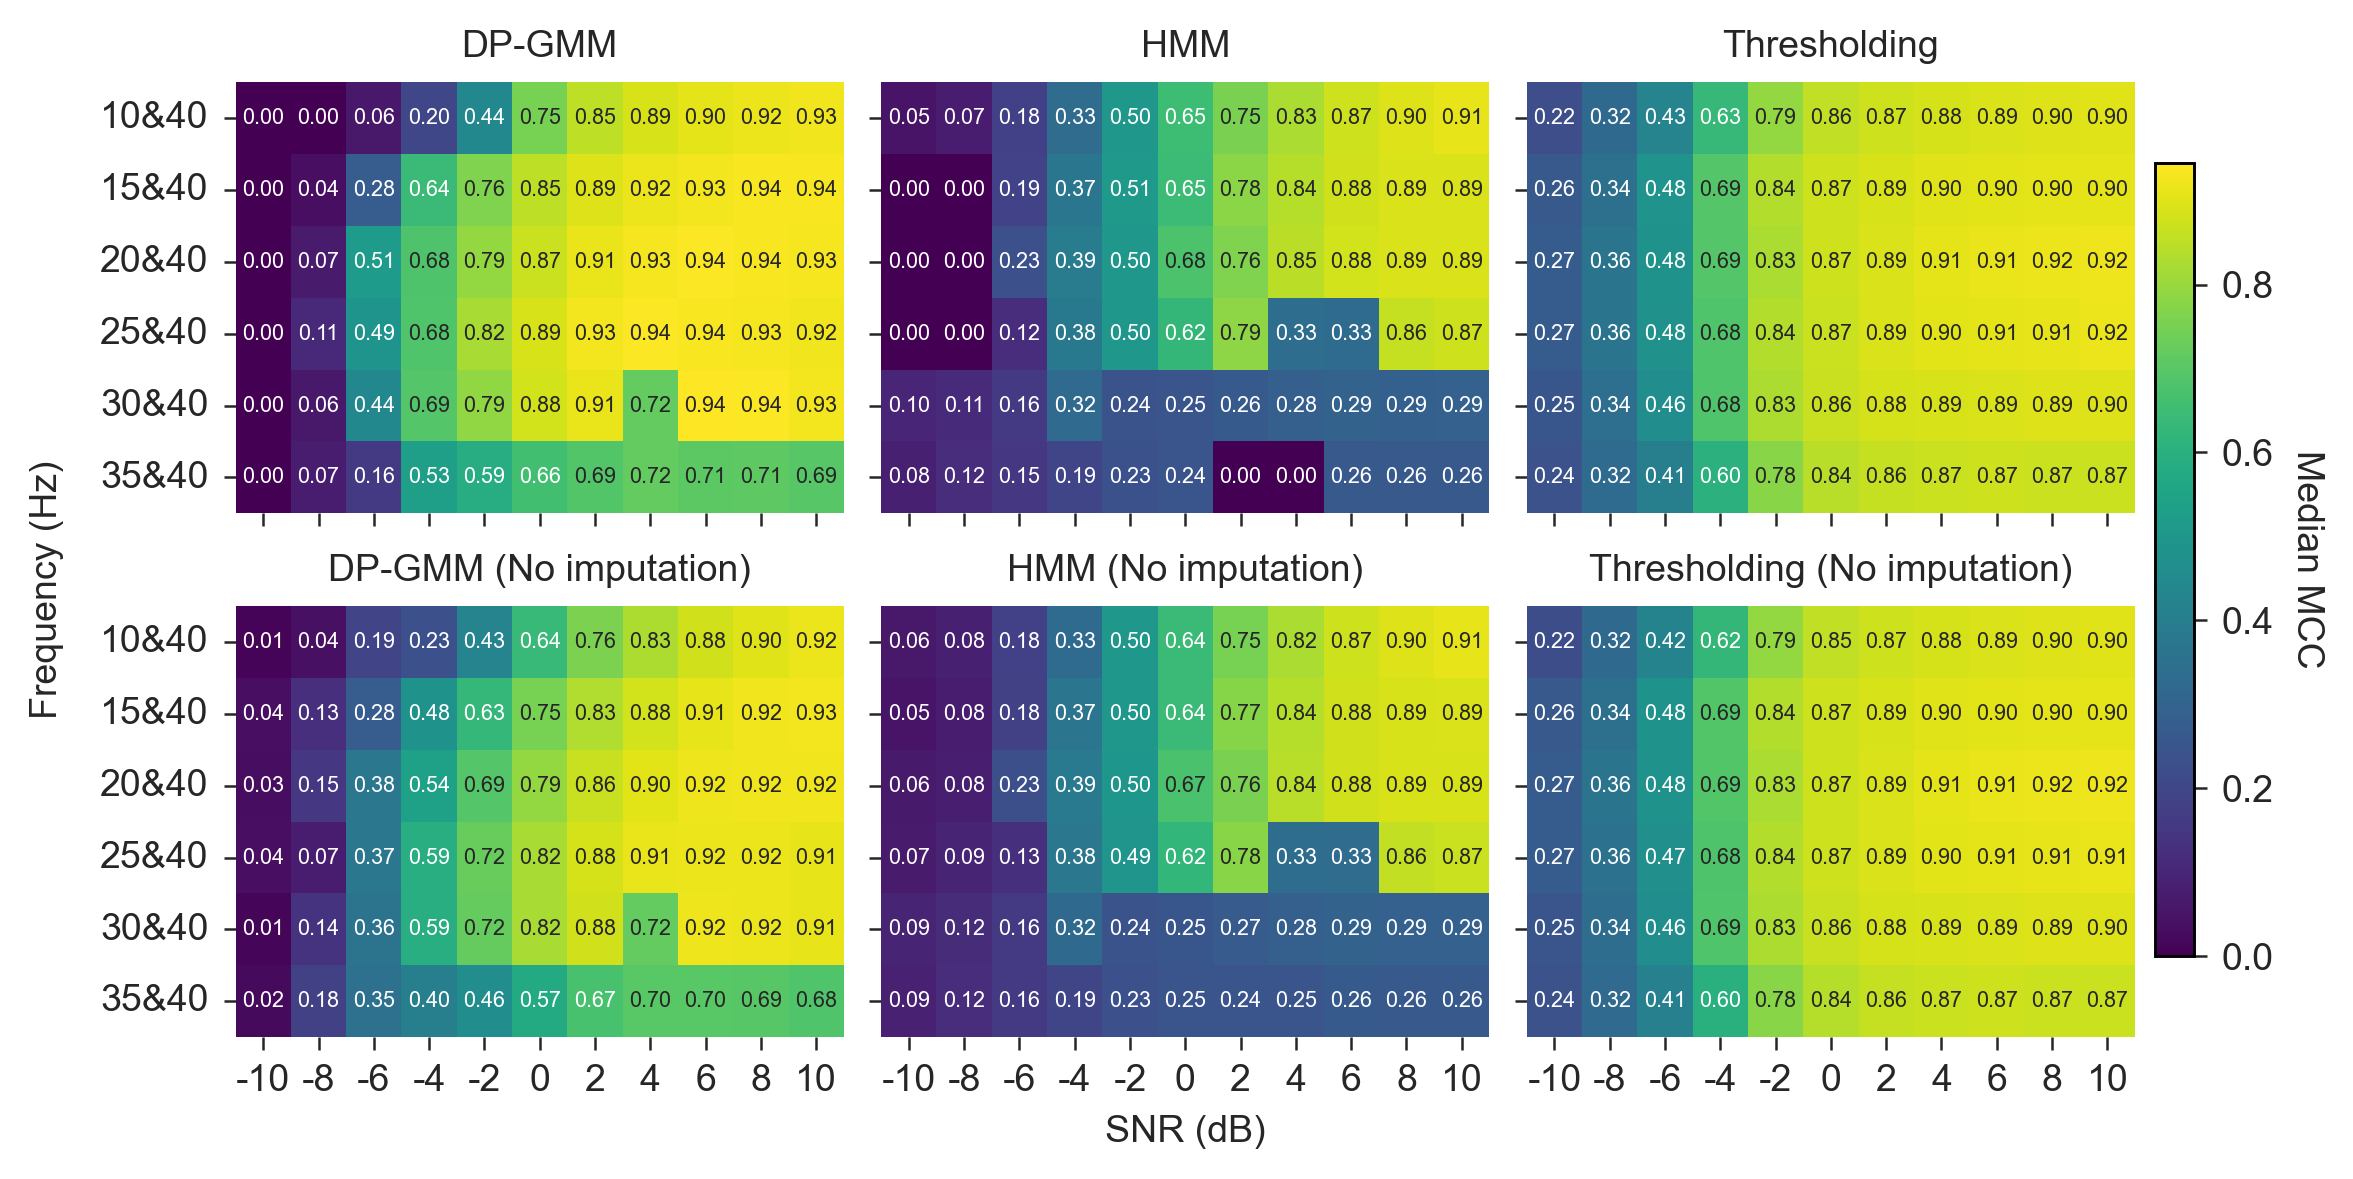

In [283]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MaxNLocator



method_names = set(df_3states.method.values)



dpgmm_heat = (df_3states.query("method == 'DP-GMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0) 
        .sort_index(axis=1))

hmm_heat = (df_3states.query("method == 'HMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending



thresh_heat = (df_3states.query("method == 'Thresholding'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0) 
        .sort_index(axis=1))




dpgmm_imputed_heat = (df_3states.query("method == 'DP-GMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0) 
        .sort_index(axis=1))


hmm_imputed_heat = (df_3states.query("method == 'HMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending


thresh_imputed_heat = (df_3states.query("method == 'Thresholding (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0) 
        .sort_index(axis=1))




mats = [
    dpgmm_heat, hmm_heat, thresh_heat,
    dpgmm_imputed_heat, hmm_imputed_heat, thresh_imputed_heat
]

vmin = np.nanmin([m.to_numpy() for m in mats])
vmax = np.nanmax([m.to_numpy() for m in mats])




common = dict(
    annot=True, fmt=".2f", annot_kws={"size": 5.2},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=False
)


fig, ax = plt.subplots(2, 3, figsize=(FIG_WIDTH, 4), sharex=True, sharey=True)

sns.heatmap(dpgmm_imputed_heat, **common, ax=ax[0,0])
ax[0,0].set_title("DP-GMM")

sns.heatmap(hmm_imputed_heat, **common, ax=ax[0,1])
ax[0,1].set_title("HMM")

sns.heatmap(thresh_imputed_heat, **common, ax=ax[0,2])
ax[0,2].set_title("Thresholding")

sns.heatmap(dpgmm_heat, **common, ax=ax[1,0])
ax[1,0].xaxis.set_major_locator(MaxNLocator(6))
ax[1,0].set_title("DP-GMM (No imputation)")

sns.heatmap(hmm_heat, **common, ax=ax[1,1])
ax[1,1].set_title("HMM (No imputation)")

sns.heatmap(thresh_heat, **common, ax=ax[1,2])
ax[1,2].set_title("Thresholding (No imputation)")






sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), fraction=0.02, pad=-0.05)
cbar.set_label("Median MCC",  rotation=270, labelpad=12)




for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")
    

fig.supylabel("Frequency (Hz)", fontsize = MY_FONT_SIZE)

ax[1,1].set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)


plt.tight_layout()

fig.savefig(
    f"../figures/{sim_cond}heatmaps.svg",
)

fig.savefig(
    f"../figures/{sim_cond}heatmaps.pdf",
)





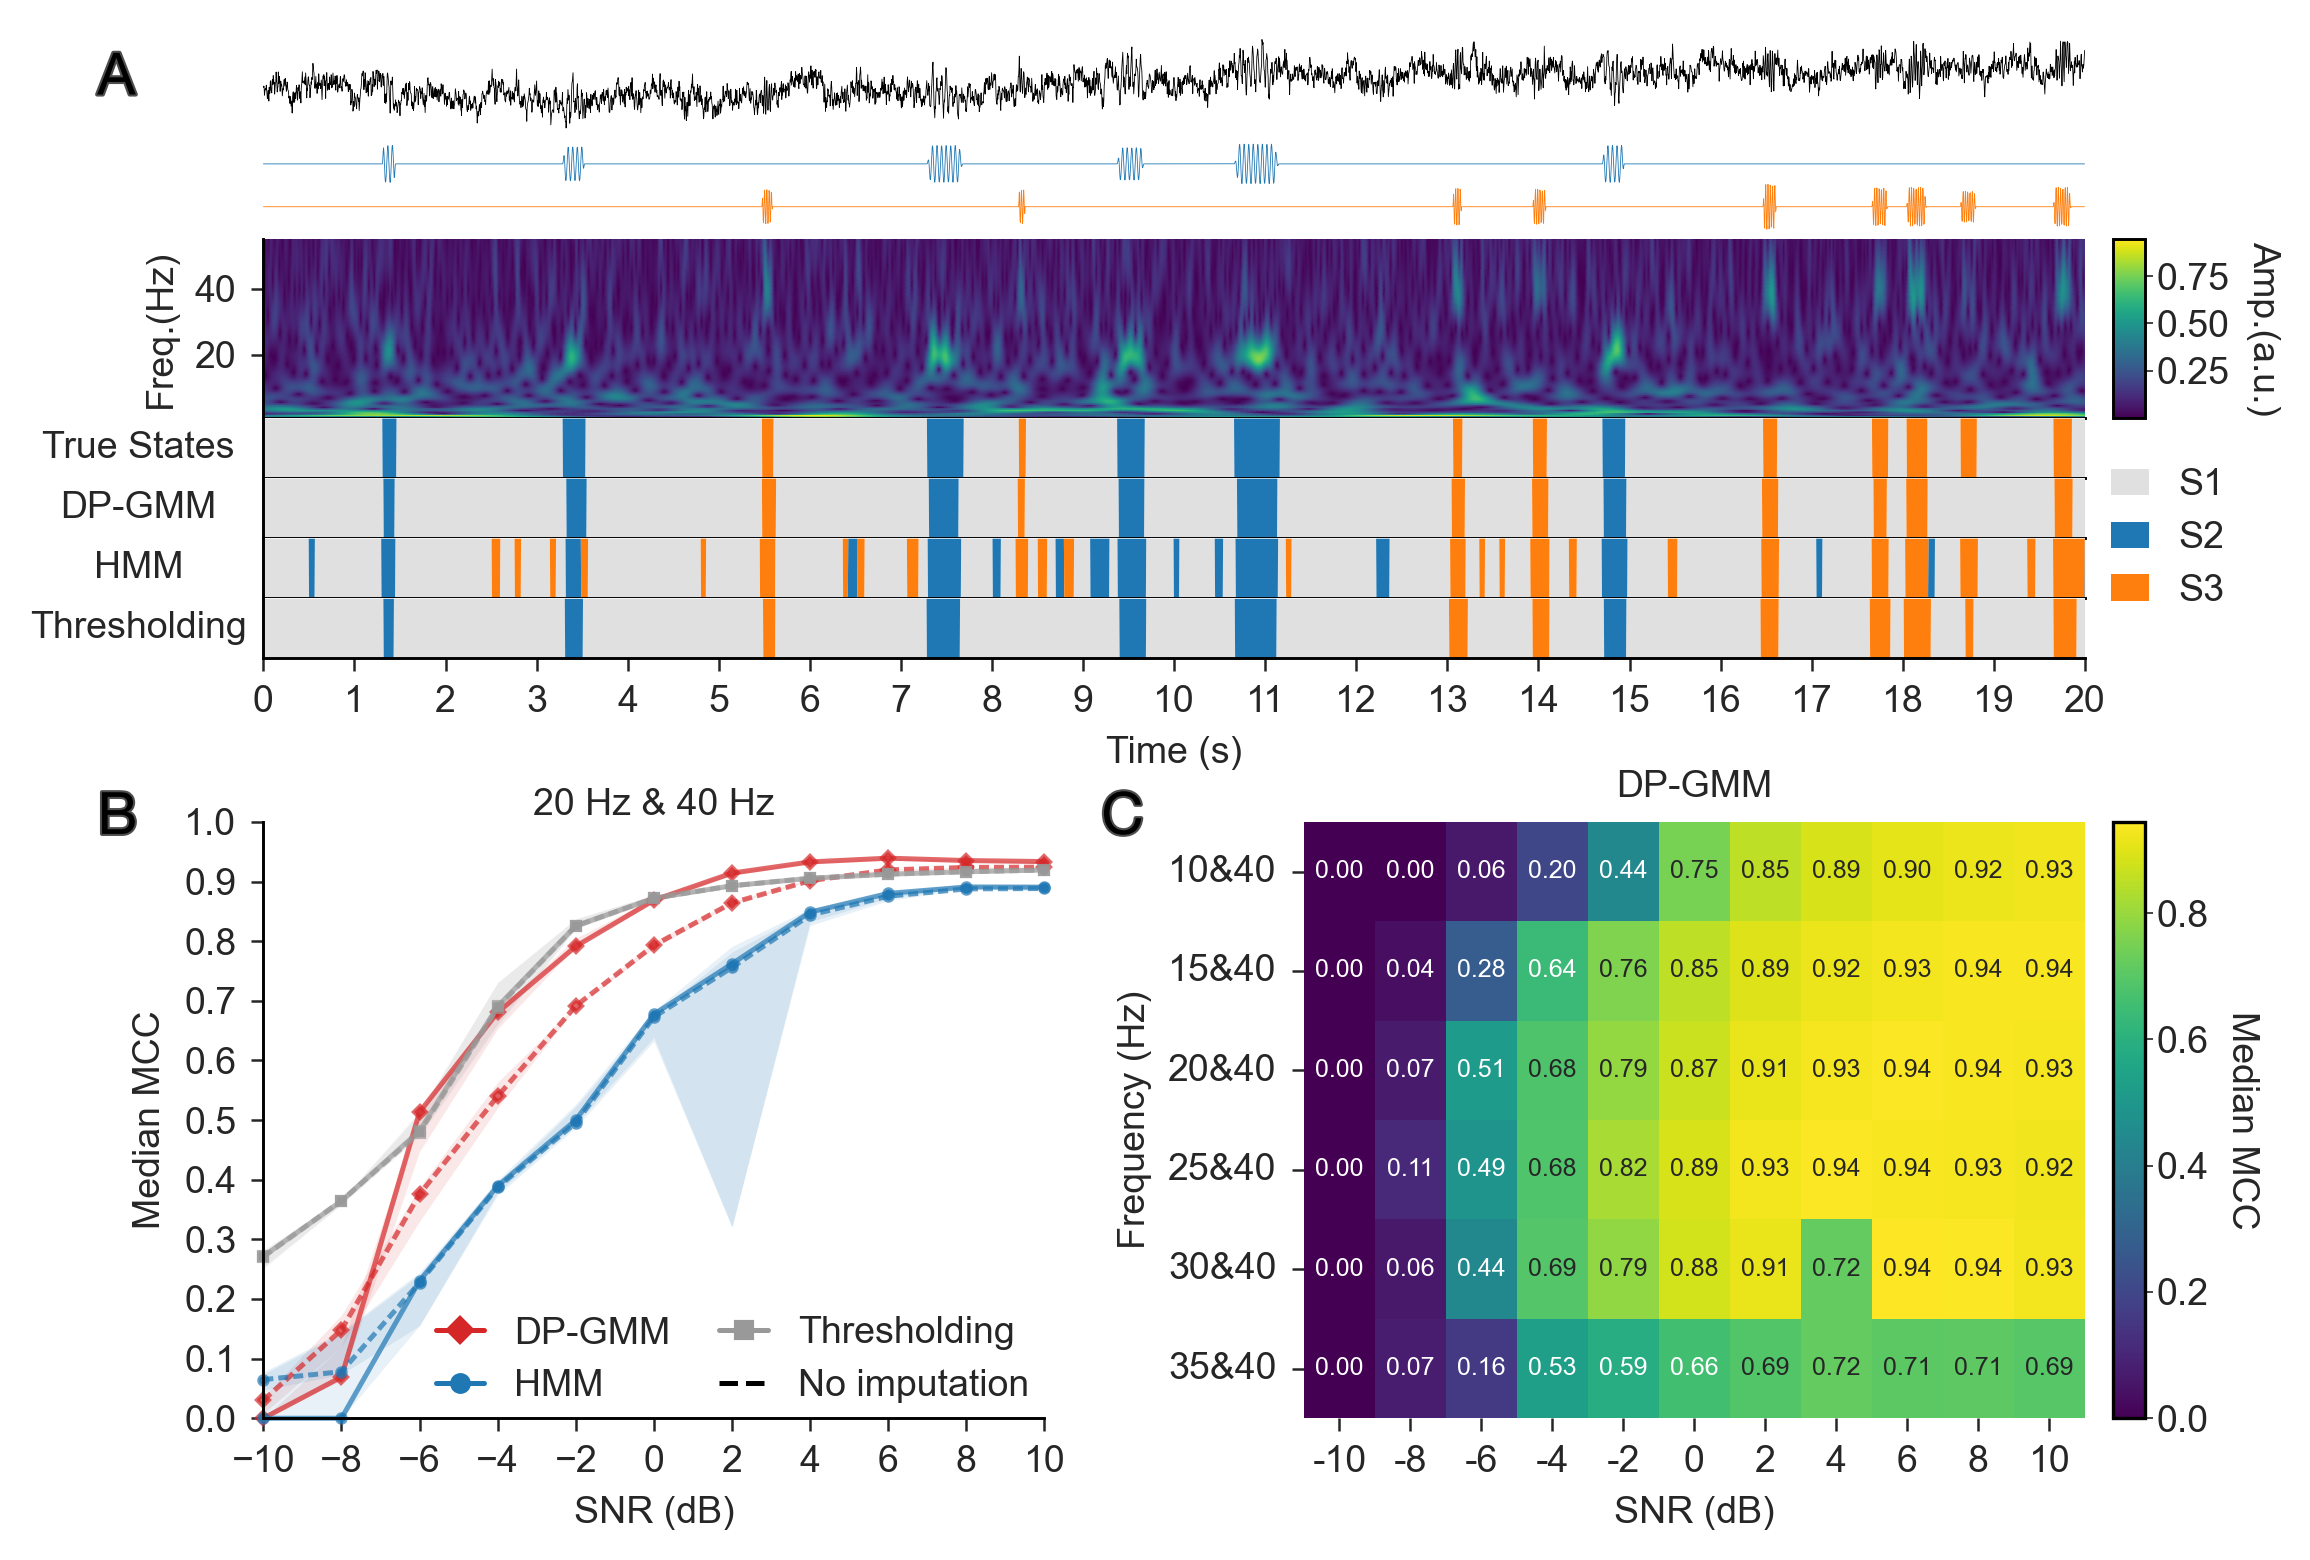

In [284]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]





mosaic = [
    ["a1", "a1", "."],
    ["a2", "a2", "cbar1"],
    ["a3", "a3", "leg"],
    ["a4", "a4", "leg"],
    ["a5", "a5", "leg"],
    ["a6", "a6", "leg"],
    ["b",  "c",  "cbar2"],
]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 5),
    constrained_layout=True,
    gridspec_kw={
        "height_ratios": [0.7, 0.6, 0.2, 0.2, 0.2, 0.2, 2],
        "width_ratios": [1, 1, 0.04,],
    }
)

fig.set_constrained_layout_pads(
    w_pad=0.0,
    h_pad=0.0,
    wspace = 0.01,
    hspace=0.001
)




##########
# simulated signal example
##########

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -2+ 1.3 *(trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -3+ 1.3 * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])



axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)

axes["a1"].grid(False)
axes["a1"].set_frame_on(False)

############
# wavelet
############
im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)

axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))
axes["a2"].set_ylim(1, 55)
axes["a2"].set_ylabel("Freq.(Hz)")


# wavelet colorbar
cb = fig.colorbar(im, cax=axes["cbar1"])
cb.set_label("Amp.(a.u.)", rotation=270, labelpad=12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



#############
# #State time courses
############
#1. true states

axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["a3"].tick_params(axis='y', which='both', left=False, labelleft=False)


#2. dpgmm (imputed)
axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors,)
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

#3. hmm (imputed)
axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, )
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

#4. threshold (imputed)
axes["a6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, )
axes["a6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")


for key in ["a3", "a4", "a5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)


for key in ["a1","a2", "a3", "a4", "a5", "a6"]:
    axes[key].sharex(axes["a6"])

axes["a6"].set_xlabel("Time (s)")
axes["a6"].xaxis.set_major_locator(MultipleLocator(1.0))
axes["a6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a6"].set_ylim(0, 1)
axes["a6"].set_xlim(0, plot_t)
axes["a6"].spines["bottom"].set_visible(True)   # keep x-axis frame


# legend for states

handles, labels = axes["a3"].get_legend_handles_labels()

axes["leg"].axis("off")
state_legend = axes["leg"].legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(-0.55, 0.5),
    bbox_transform=axes["leg"].transAxes,
    frameon=False,
    handlelength=1,
    borderaxespad=0.0,
)

state_legend.set_in_layout(False)




###########
#MCC lineplot
###########

thresh_color = "#999999" # grey
hmm_color   = "#1f77b4"  # vivid blue
dpgmm_color   = "#d62728"

palette = {
    "Thresholding":                 thresh_color,
    "Thresholding (Imputed)":     thresh_color,
    "HMM":                   hmm_color,
    "HMM (Imputed)":       hmm_color,
    "DP-GMM":                 dpgmm_color,
    "DP-GMM (Imputed)":     dpgmm_color,
}

dashes = {
    "Thresholding":               (2, 1),      # dashed
    "Thresholding (Imputed)":   (None, None),# solid
    "HMM":                 (2, 1),
    "HMM (Imputed)":     (None, None),
    "DP-GMM":               (2, 1),
    "DP-GMM (Imputed)":   (None, None),
}

markers = {
    "Thresholding":               "s",   # square
    "Thresholding (Imputed)":   "s",
    "HMM":                 "o",   # circle
    "HMM (Imputed)":     "o",
    "DP-GMM":               "D",   # diamond
    "DP-GMM (Imputed)":   "D",
}


handles_left = [
    Line2D([0], [0], color=dpgmm_color, marker="D", lw=1.2, ms=4, linestyle="-", label="DP-GMM"),
    Line2D([0], [0], color=hmm_color, marker="o", lw=1.2, ms=4, linestyle="-", label="HMM"),
    Line2D([0], [0], color=thresh_color, marker="s", lw=1.2, ms=4, linestyle="-", label="Thresholding"),
]

handles_right = [
    Line2D([0], [0], color="k", lw=1.2, linestyle="--", label="No imputation")  # dashed example
]
handles = handles_left + handles_right
labels  = [h.get_label() for h in handles]


for method in df_median["method"].unique():
    df_sub = (
        df_median[df_median["method"] == method]
        .sort_values("snr")
    )

    label = method.replace("_", " ")

    # Median line
    axes["b"].plot(
        df_sub["snr"],
        df_sub["mcc_median"],
        label=label,
        color=palette[method],
        marker=markers[method],
        linestyle="-" if dashes[method] == (None, None) else (0, dashes[method]),
        lw=1.2,
        ms=2,
        alpha=0.7,
        clip_on=False,
    )

    # Interquartile range: 25th to 75th percentile
    axes["b"].fill_between(
        df_sub["snr"],
        df_sub["mcc_q25"],
        df_sub["mcc_q75"],
        color=palette[method],
        alpha=0.1,
        clip_on=True,
        linewidth=0,
    )
axes["b"].set_xticks(snr_range)
axes["b"].set_xlim(min(snr_range), max(snr_range))
axes["b"].set_ylim(0, 1)
axes["b"].yaxis.set_major_locator(MultipleLocator(0.1))
#axes["a"].yaxis.set_minor_locator(MultipleLocator(0.05))
#axes["a"].grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
axes["b"].set_xlabel("SNR (dB)")
axes["b"].set_ylabel("Median MCC")
axes["b"].set_title(f"{plot_f[0]} Hz & {plot_f[1]} Hz",pad = 0.3)


#legend
axes["b"].legend(
    handles, labels,
    ncols=2,
    loc="lower right",
    frameon=False,
    columnspacing=1.3,
    handlelength=1.3,
    borderaxespad=0.0,
)




#############
# MCC heatmap
############

sns.heatmap(
    dpgmm_imputed_heat,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=True,
    cbar_ax=axes["cbar2"],
    ax=axes["c"]
)

cbar = axes["c"].collections[0].colorbar
cbar.set_label("Median MCC", rotation=270, labelpad=12)
cbar.ax.tick_params(which="both", length=2, width=0.4, pad=1)
cbar.outline.set_visible(True)
cbar.outline.set_linewidth(0.8)


axes["c"].set_title("DP-GMM")
axes["c"].set_xlabel("SNR (dB)")
axes["c"].set_ylabel("Frequency (Hz)")

###########
# panel label
###########

import matplotlib.patheffects as pe
from matplotlib.font_manager import FontProperties


# Finalize constrained_layout positions before reading axes positions
fig.canvas.draw()
fig.set_constrained_layout(False)




panel_font = FontProperties(
    family="Helvetica Neue",
    weight="heavy",
    size=14,
)

label_kw = dict(
    fontproperties=panel_font,
    color="k",
    ha="left",
    va="top",
    path_effects=[
        pe.withStroke(linewidth=1, foreground="0.30")
    ],
)

# Get axes positions in figure coordinates
pos_a = axes["a1"].get_position()
pos_b = axes["b"].get_position()
pos_c = axes["c"].get_position()

# A and B aligned to the same absolute figure x-position
x_left = 0.030

fig.text(
    x_left,
    min(pos_a.y1 + 0.035, 0.985),
    "A",
    transform=fig.transFigure,
    **label_kw,
)

fig.text(
    x_left,
    pos_b.y1 + 0.020,
    "B",
    transform=fig.transFigure,
    **label_kw,
)

fig.text(
    pos_c.x0 - 0.09,
    pos_c.y1 + 0.020,
    "C",
    transform=fig.transFigure,
    **label_kw,
)



fig.savefig(
    f"../figures/{sim_cond}_results.svg",
    format="svg",
    bbox_inches="tight",
    bbox_extra_artists=[state_legend],
    pad_inches=0.02,
)



fig.savefig(
    f"../figures/{sim_cond}_results.pdf",
    format="pdf",
    bbox_inches="tight",
    bbox_extra_artists=[state_legend],
    pad_inches=0.02,
)




## performance before imputation

In [286]:

dpgmm_res = res.query("method == 'DP-GMM'").iloc[sample_id]
hmm_res = res.query("method == 'HMM'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding'").iloc[sample_id]


hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc

thresh_states = thresh_res.est_states
thresh_states = trim_data(thresh_states, num_emb_hmm)




dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc


#crop dpgmm to align with hmm
left_gmm = num_emb_dpgmm // 2
right_gmm = num_emb_dpgmm - 1 - left_gmm

left_hmm = num_emb_hmm // 2
right_hmm = num_emb_hmm - 1 - left_hmm

crop_left = left_hmm - left_gmm
crop_right = right_hmm - right_gmm
dpgmm_states = dpgmm_states[crop_left:-crop_right]

dpgmm_states_onehot = np.eye(num_states)[dpgmm_states]



print(trimmed_states.shape)
print(dpgmm_states_onehot.shape)
print(hmm_states_onehot.shape)
print(thresh_states_onehot.shape)



Lost 12 data points were lost from both ends.
data shape: (44976,)
(44976,)
(44976, 3)
(44976, 3)
(44976, 3)


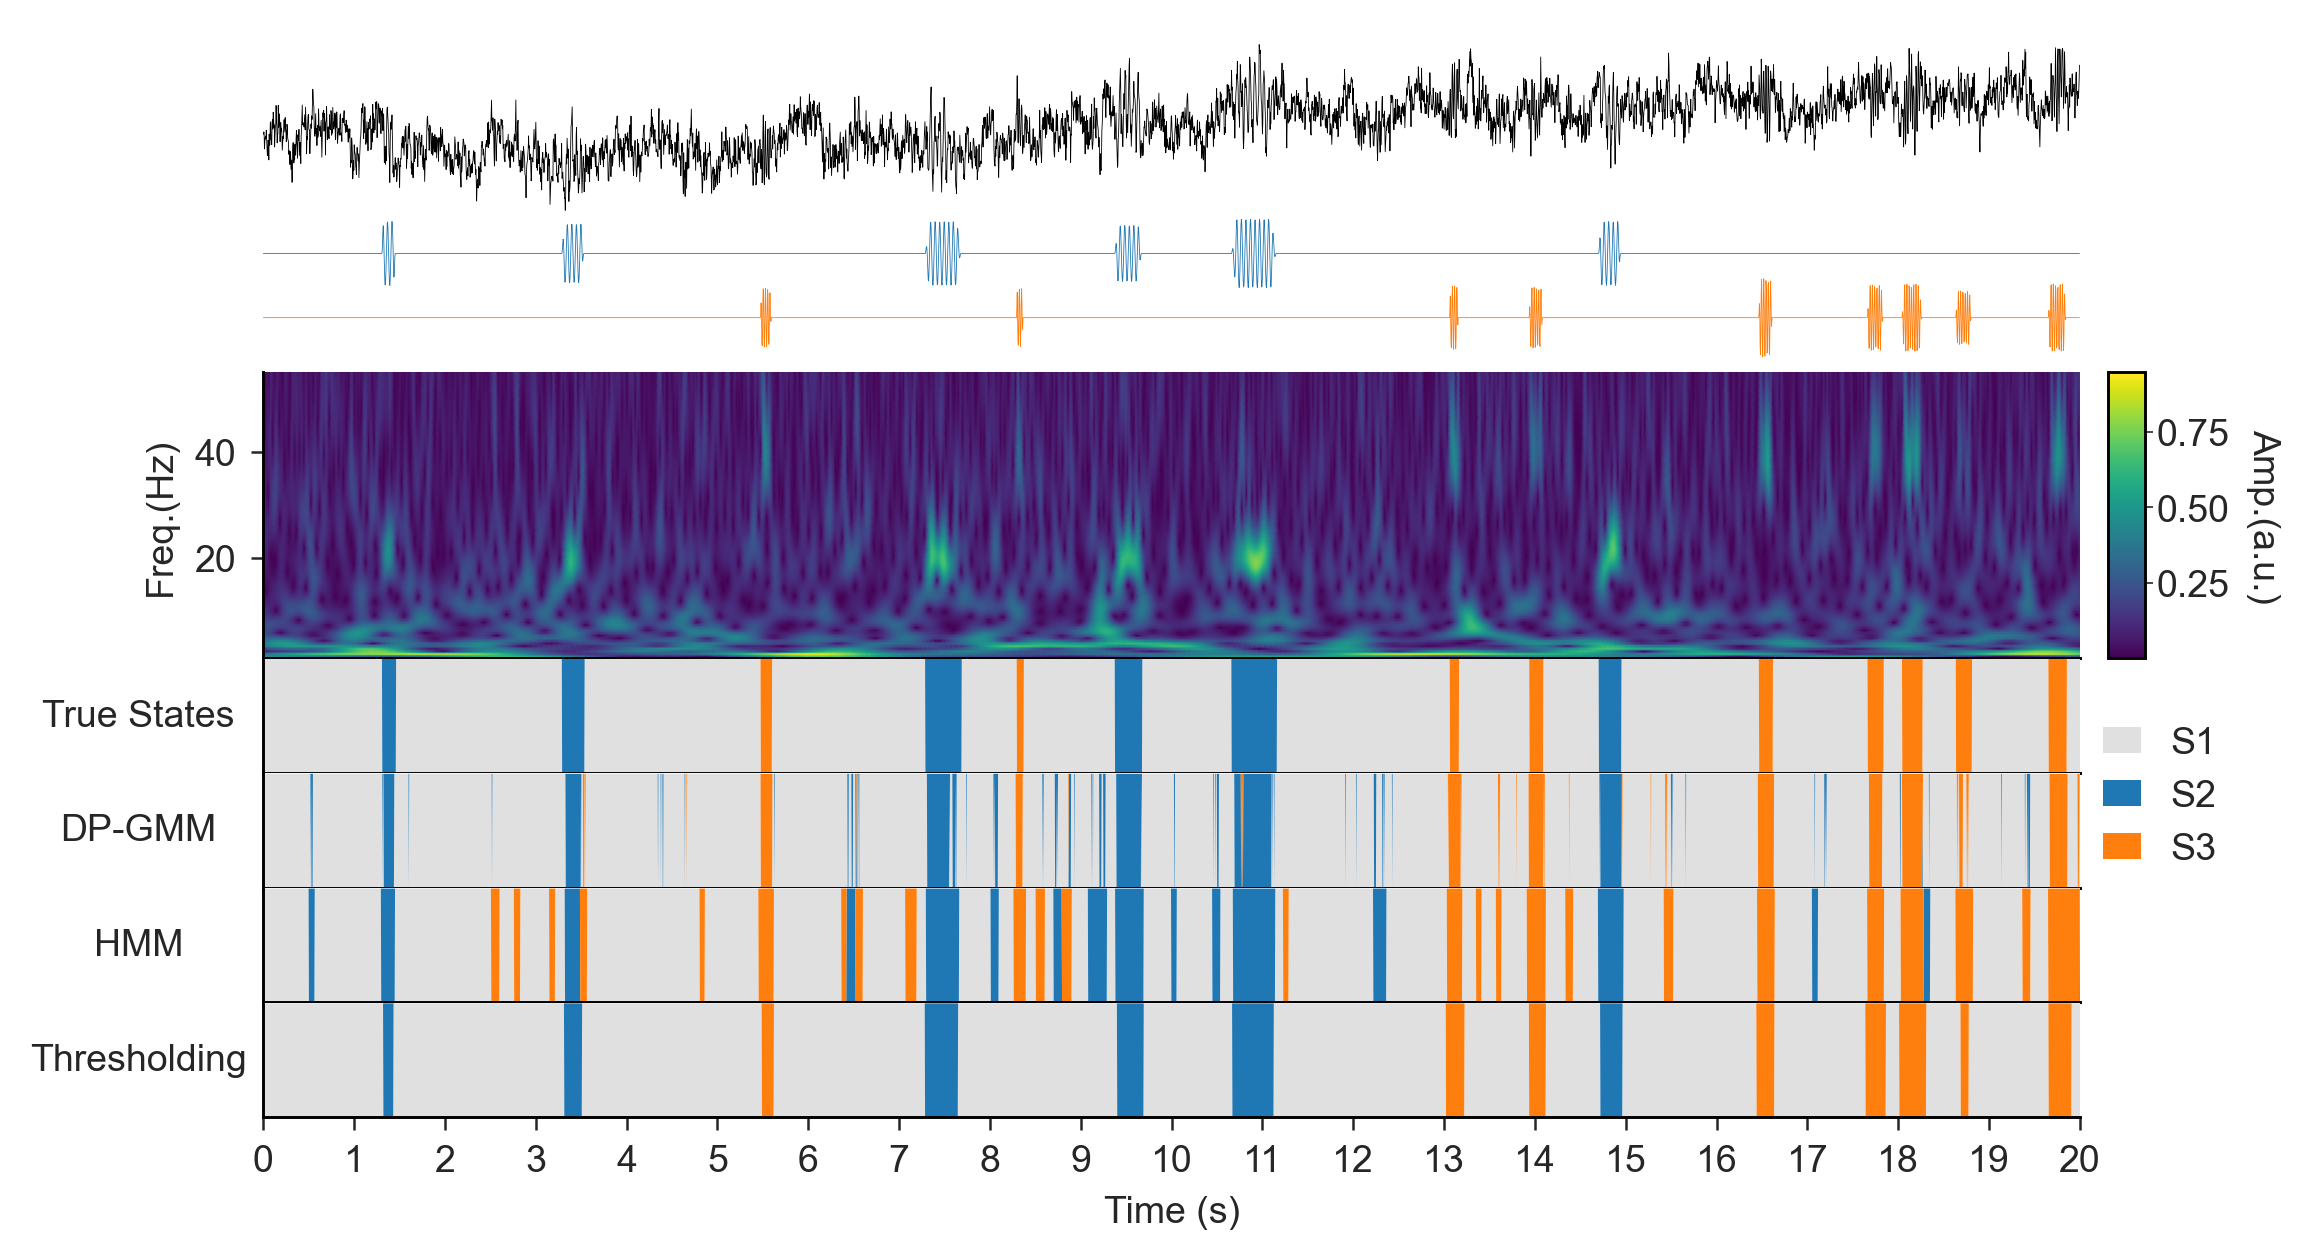

In [287]:


import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D





plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]



mosaic = [
    ["a1", "a1", "."],
    ["a2", "a2", "cbar1"],
    ["a3", "a3", "leg"],
    ["a4", "a4", "leg"],
    ["a5", "a5", "leg"],
    ["a6", "a6", "leg"],]



fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4),
    constrained_layout=True,
    gridspec_kw={
        "height_ratios": [0.6, 0.5, 0.2, 0.2, 0.2, 0.2,],
        "width_ratios": [1, 1, 0.04,],
    }
)


fig.set_constrained_layout_pads(
    w_pad=0.0,
    h_pad=0.0,
    wspace = 0.01,
    hspace=0.001
)




##########
# simulated signal example
##########

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].grid(False)
axes["a1"].set_frame_on(False)


axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -1.7+ 1.2 *(trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -2.5+ 1.2 * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])



axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)



############
# wavelet
############
im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)

axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))
axes["a2"].set_ylim(1, 55)
axes["a2"].set_ylabel("Freq.(Hz)")


# wavelet colorbar
cb = fig.colorbar(im, cax=axes["cbar1"])
cb.set_label("Amp.(a.u.)", rotation=270, labelpad=12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



#############
# #State time courses
############
#1. true states

axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["a3"].tick_params(axis='y', which='both', left=False, labelleft=False)


#2. dpgmm (imputed)
axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors,)
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

#3. hmm (imputed)
axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, )
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

#4. threshold (imputed)
axes["a6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, )
axes["a6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")


for key in ["a3", "a4", "a5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)


for key in ["a1","a2", "a3", "a4", "a5", "a6"]:
    axes[key].sharex(axes["a6"])

axes["a6"].set_xlabel("Time (s)")
axes["a6"].xaxis.set_major_locator(MultipleLocator(1.0))
axes["a6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a6"].set_ylim(0, 1)
axes["a6"].set_xlim(0, plot_t)
axes["a6"].spines["bottom"].set_visible(True)   # keep x-axis frame


# legend for states

handles, labels = axes["a3"].get_legend_handles_labels()

axes["leg"].axis("off")
state_legend = axes["leg"].legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(-0.55, 0.7),
    bbox_transform=axes["leg"].transAxes,
    frameon=False,
    handlelength=1,
    borderaxespad=0.0,
)

state_legend.set_in_layout(False)




fig.savefig(
    f"../figures/{sim_cond}_before_imputation.svg",
    format="svg",
    bbox_inches="tight",
    bbox_extra_artists=(state_legend,),
    pad_inches=0.02,
)



fig.savefig(
    f"../figures/{sim_cond}_before_imputation.pdf",
    bbox_inches="tight",
    bbox_extra_artists=(state_legend,),
    pad_inches=0.02,

)





# 4 states scenario

In [325]:
sim_cond = "4states"
data_dir = "../data/simulations"
data_file = f"{data_dir}/{sim_cond}_data.npz"

sim_data = np.load(data_file)

signal = sim_data["signal_sample"]
states = sim_data["states_sample"]
bursts = sim_data["bursts_sample"]


import pickle
performance_dir = "../data/performance"
save_path = os.path.join(performance_dir, f"{sim_cond}_res.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)


res = pd.DataFrame(res)
res.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-0.22835210505363163, 0.2822218021130409, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[20, 30, 40]",250,0,"{'alpha': 0.5523994, 'weights': [0.7402009, 0....",0.8011745,6.0,975381835.0,...,0.548454,82.681902,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3]",{'fractional_occupancies': [0.8305913739439751...,0.786798,0.8011745,NaN
1,DP-GMM (Edge-removed),"[-0.22835210505363163, 0.2822218021130409, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[20, 30, 40]",250,0,"{'alpha': 0.5523994, 'weights': [0.7402009, 0....",0.8011745,6.0,975381835.0,...,0.548454,82.681902,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3]",{'fractional_occupancies': [0.8555580257892397...,0.862860,0.8011745,NaN
2,DP-GMM (Imputed),"[-0.22835210505363163, 0.2822218021130409, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[20, 30, 40]",250,0,"{'alpha': 0.5523994, 'weights': [0.7402009, 0....",0.8011745,6.0,975381835.0,...,0.548454,82.681902,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3]",{'fractional_occupancies': [0.8555580257892397...,0.862860,0.8011745,NaN
3,DP-GMM (Imputed & Edge-removed),"[-0.22835210505363163, 0.2822218021130409, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[20, 30, 40]",250,0,"{'alpha': 0.5523994, 'weights': [0.7402009, 0....",0.8011745,6.0,975381835.0,...,0.548454,82.681902,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3]",{'fractional_occupancies': [0.8555580257892397...,0.862860,0.8011745,NaN
4,HMM,"[-0.22835210505363163, 0.2822218021130409, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[20, 30, 40]",250,0,"{'initial_probs': [0.06052478, 0.14768144, 0.0...",0.731342,NaN,NaN,...,0.195485,980.836802,11,25,"[6, 6, 6, 6, 5, 5, 5, 0, 0, 0, 8, 8, 8, 8, 8, ...","[4, 9, 1, 5, 0, 2, 3, 6, 7, 8, 10]",{'fractional_occupancies': [0.1233991462113127...,0.294815,0.731342,19.0


In [326]:
from nds_toolbox.preprocessing.features import compute_tde, trim_data, choose_embedding_dim


n_seconds = 60*3  # Total duration in seconds.
fs = 250

snr_db = 0

freq = np.array([20, 30, 40])  #ground truth = 4 states (including noise state)



In [345]:
hmm_res = res.query("method == 'HMM (Imputed)'")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'")

hmm_row = hmm_res.iloc[0]
dpgmm_row = dpgmm_res.iloc[0]


T = len(states)


# ---------------------------------------------------------------------
# HMM results
# ---------------------------------------------------------------------

num_emb_hmm = int(hmm_row["num_emb"])

hmm_states = np.asarray(hmm_row["est_states"]).astype(int, copy=False)
hmm_mcc = hmm_row["mcc"]

hmm_summary_stats = hmm_row["summary_stats"]
hmm_fo = hmm_summary_stats["fractional_occupancies"]
hmm_f, hmm_psds = hmm_summary_stats["spectra"]

init_probs, trans_mat, hmm_means, hmm_covs, stationary_dist = (
    hmm_row["est_params"].values()
)


# ---------------------------------------------------------------------
# DP-GMM results
# ---------------------------------------------------------------------

num_emb_dpgmm = int(dpgmm_row["num_emb"])

gmm_states = np.asarray(dpgmm_row["est_states"]).astype(int, copy=False)
gmm_mcc = dpgmm_row["mcc"]

gmm_summary_stats = dpgmm_row["summary_stats"]
gmm_fo = gmm_summary_stats["fractional_occupancies"]
gmm_f, gmm_psds = gmm_summary_stats["spectra"]

alpha, weights, gmm_means, gmm_covs, untrunc_means, untrunc_covs, untrunc_weights, trunc_info, num_active_states = (
    dpgmm_row["est_params"].values()
)


# ---------------------------------------------------------------------
# Compute valid supports for each embedding
# ---------------------------------------------------------------------

left_hmm = num_emb_hmm // 2
right_hmm = num_emb_hmm - 1 - left_hmm

left_gmm = num_emb_dpgmm // 2
right_gmm = num_emb_dpgmm - 1 - left_gmm

hmm_start = left_hmm
hmm_end = T - right_hmm

gmm_start = left_gmm
gmm_end = T - right_gmm

expected_hmm_len = hmm_end - hmm_start
expected_gmm_len = gmm_end - gmm_start

if len(hmm_states) != expected_hmm_len:
    raise ValueError(
        f"HMM state length mismatch: expected {expected_hmm_len}, "
        f"got {len(hmm_states)}."
    )

if len(gmm_states) != expected_gmm_len:
    raise ValueError(
        f"DP-GMM state length mismatch: expected {expected_gmm_len}, "
        f"got {len(gmm_states)}."
    )


# ---------------------------------------------------------------------
# Align HMM, DP-GMM, true states, signal, and bursts to common support
# ---------------------------------------------------------------------

common_start = max(hmm_start, gmm_start)
common_end = min(hmm_end, gmm_end)

if common_start >= common_end:
    raise ValueError(
        "No overlapping valid support between HMM and DP-GMM. "
        f"HMM support=({hmm_start}, {hmm_end}), "
        f"DP-GMM support=({gmm_start}, {gmm_end})."
    )


# Crop HMM states to common support
hmm_crop_left = common_start - hmm_start
hmm_crop_right = hmm_end - common_end

hmm_right_idx = None if hmm_crop_right == 0 else -hmm_crop_right
hmm_states = hmm_states[hmm_crop_left:hmm_right_idx]


# Crop DP-GMM states to common support
gmm_crop_left = common_start - gmm_start
gmm_crop_right = gmm_end - common_end

gmm_right_idx = None if gmm_crop_right == 0 else -gmm_crop_right
gmm_states = gmm_states[gmm_crop_left:gmm_right_idx]


# Crop true data to common support
trimmed_signal = signal[common_start:common_end]
trimmed_states = states[common_start:common_end].astype(int)
trimmed_bursts = bursts[common_start:common_end]

trimmed_time_vec = np.arange(len(trimmed_states)) / fs


hmm_states_onehot = np.eye(num_states)[hmm_states]
gmm_states_onehot = np.eye(num_states)[gmm_states]
states_onehot = np.eye(num_states)[trimmed_states]



In [346]:
print(trimmed_states_onehot.shape)
print(gmm_states_onehot.shape)
print(hmm_states_onehot.shape)



(44976, 11)
(44976, 11)
(44976, 11)


In [347]:
state_labels

['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11']

In [342]:
num_states

11

['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11']


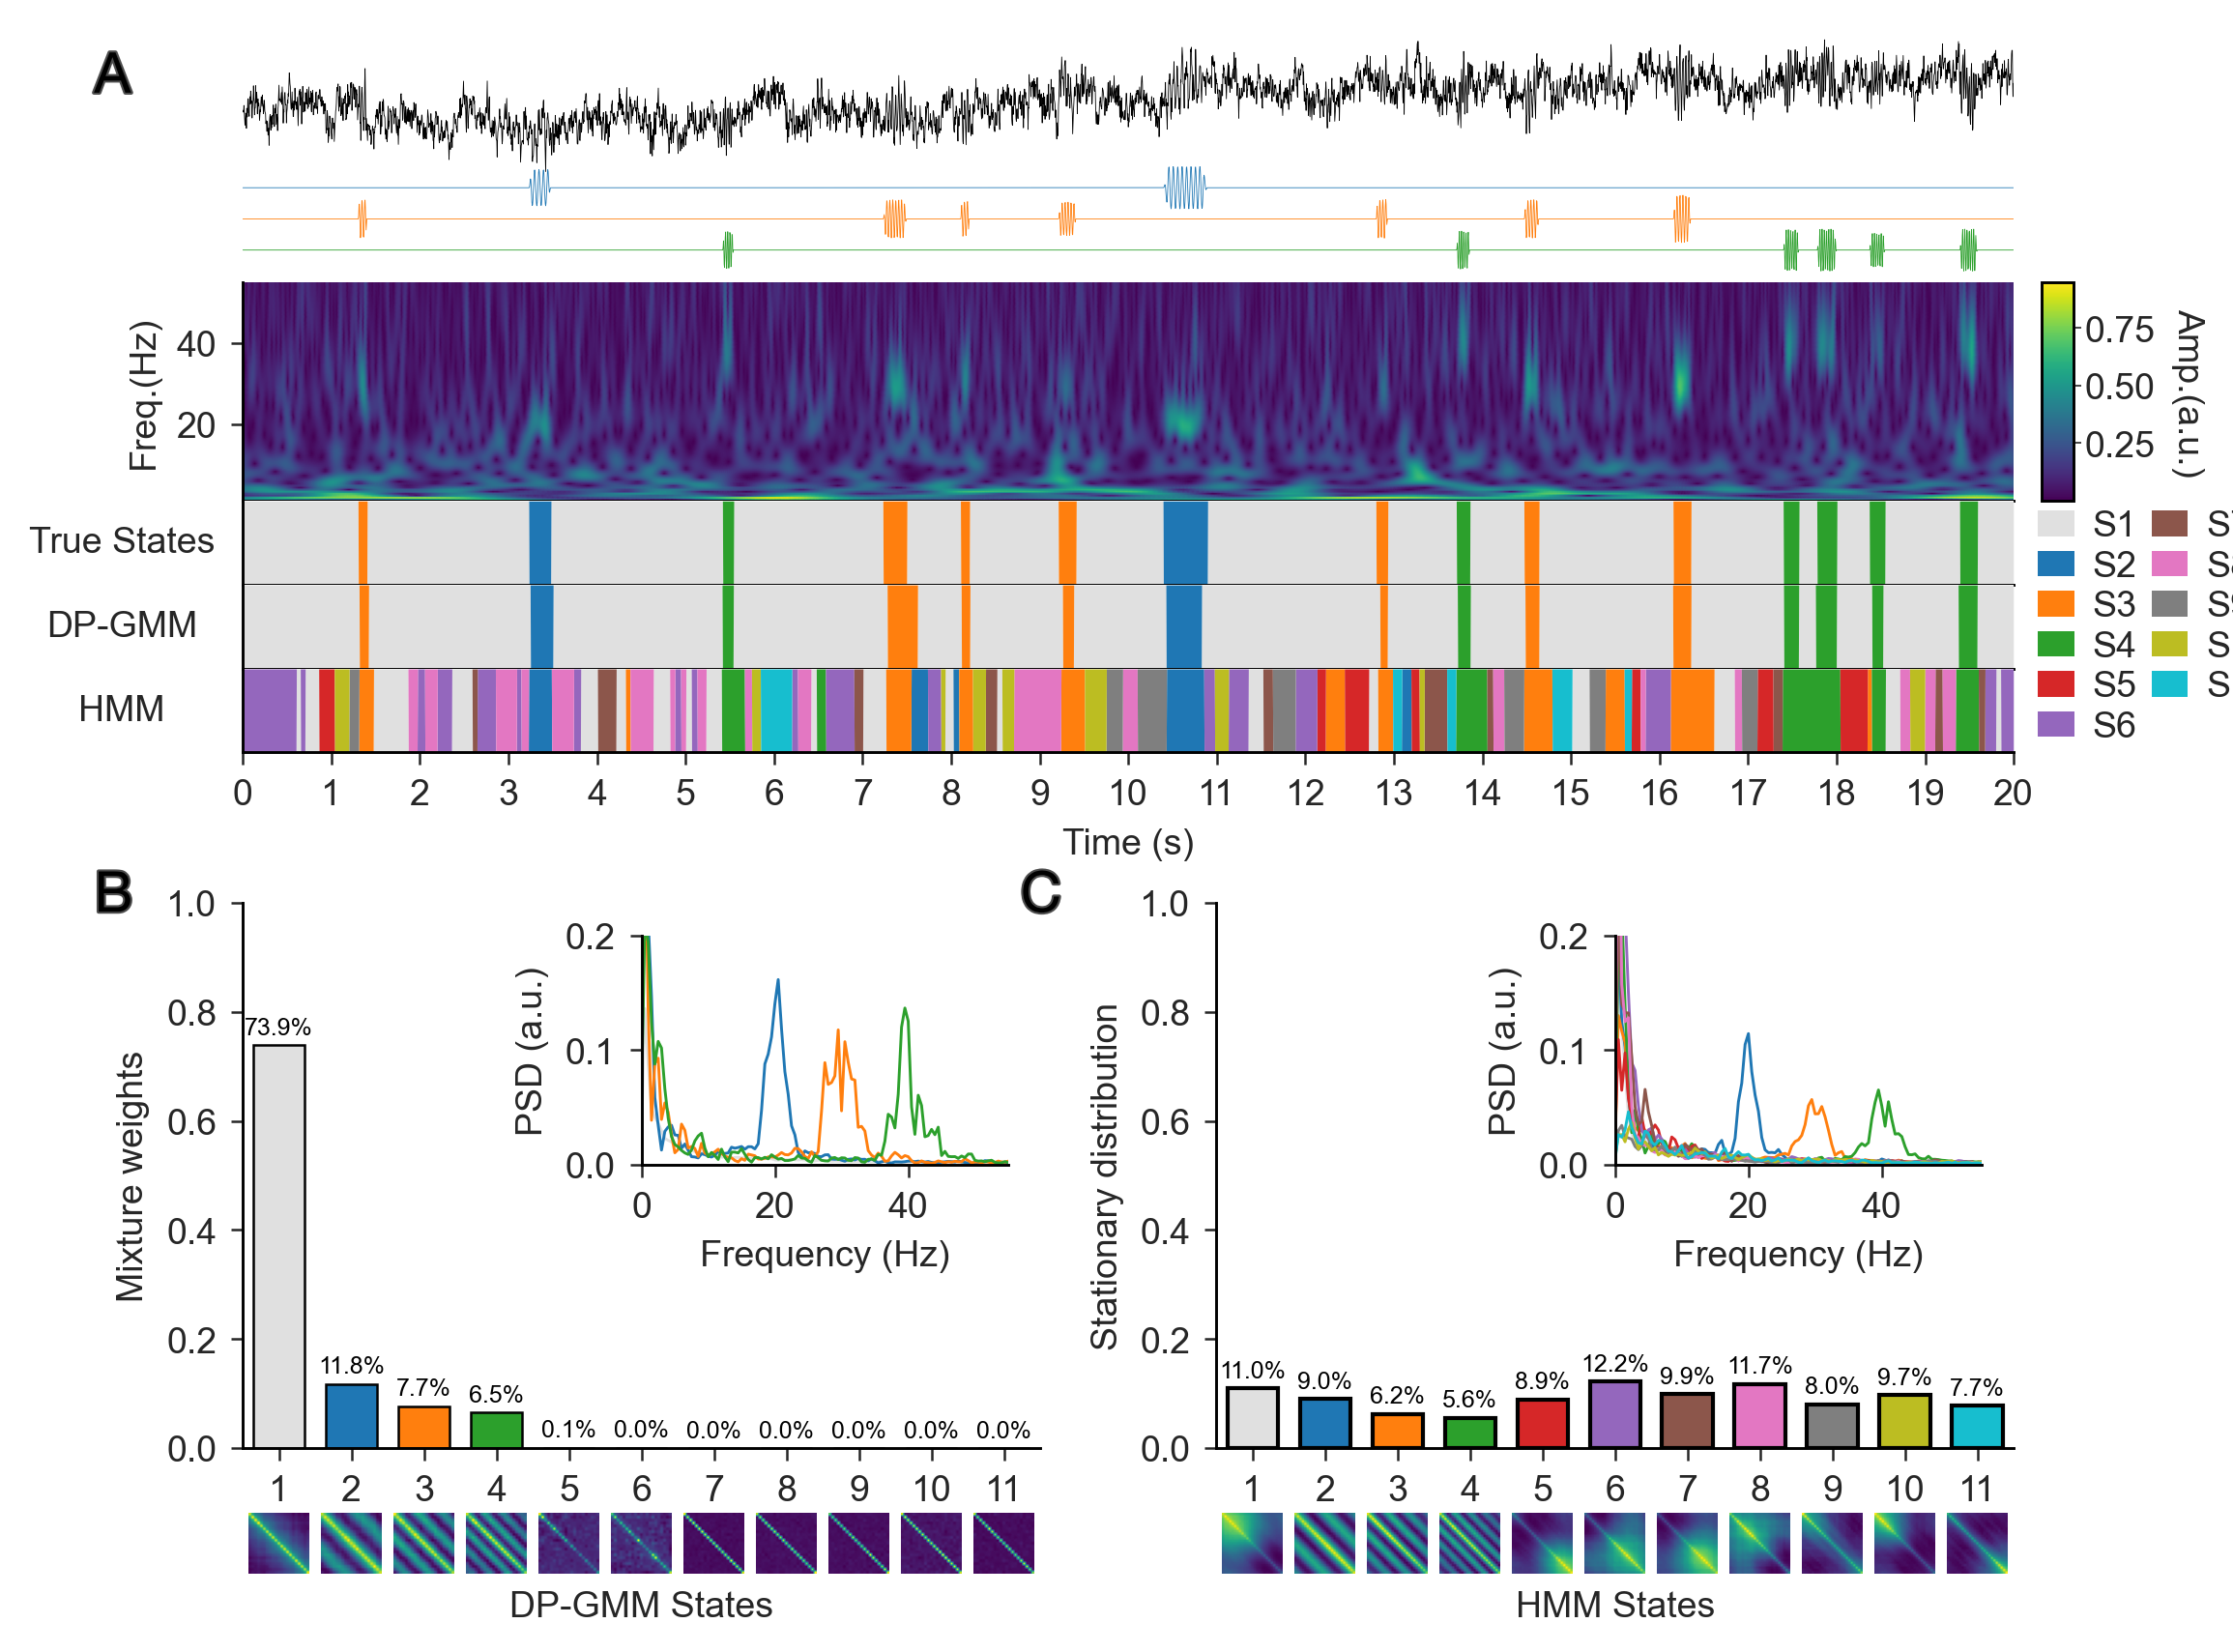

In [391]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1", "."],
          ["a2", "a2", "cbar1"],
          ["a3", "a3", "leg"],
          ["a4", "a4", "leg"],
          ["a5", "a5", "leg"],
          ["gap", "gap", "."],
          ["b", "c", "."],
          ["d", "e", "."],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 5.5),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.23,0.23,0.23, 0.08, 1.5, 0.2],
                 "width_ratios": [1, 1, 0.04]}
)
fig.set_constrained_layout_pads(
    w_pad=0.0,
    h_pad=0.0,
    wspace = 0.01,
    hspace=0.001
)

axes["gap"].axis("off")


##########
# simulated signal example
##########

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], 2*trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].grid(False)


scale_burst = 1.9

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -3+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -4+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])


axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)

axes["a1"].grid(False)
axes["a1"].set_frame_on(False)


############
# wavelet
############
im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)

axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))
axes["a2"].set_ylim(1, 55)
axes["a2"].set_ylabel("Freq.(Hz)")


# wavelet colorbar
cb = fig.colorbar(im, cax=axes["cbar1"])
cb.set_label("Amp.(a.u.)", rotation=270, labelpad=12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)




#############
# #State time courses
############
#1. true states

axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["a3"].tick_params(axis='y', which='both', left=False, labelleft=False)


#2. dpgmm (imputed)
axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors,)
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

#3. hmm (imputed)
axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)


for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a5"])


axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)
axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame



# legend for states

handles, labels = axes["a5"].get_legend_handles_labels()

axes["leg"].axis("off")
state_legend = axes["leg"].legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(-0.55, 0.5),
    bbox_transform=axes["leg"].transAxes,
    frameon=False,
    handlelength=1,
    handletextpad=0.5,
    labelspacing=0.2,
    borderaxespad=0.0,
    ncol=2,
    columnspacing=0.4,
)

state_legend.set_in_layout(False)


print(labels)

##########
# mixture weights
###########

axes["b"].bar(
    np.arange(num_states),
    untrunc_weights,
    width=0.7,
    color=colors[:num_states],
    edgecolor="k",
    linewidth=0.6,
    zorder=2,
)


for k, w in enumerate(untrunc_weights):
    axes["b"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k" , fontsize = MY_FONT_SIZE - 3 )
    axes["b"].set_ylabel("Mixture weights")
    axes["b"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["b"].tick_params(axis='y')

   #axes["c"].spines["top"].set_visible(True)
    #axes["c"].spines["right"].set_visible(True)
    axes["b"].set_ylim(0, 1)


#inset: dpgmm state psd
b_inset = axes["b"].inset_axes([0.50, 0.52, 0.46, 0.42])

for i in range(num_active_states):
    b_inset.plot(gmm_f[i], gmm_psds[i], color=colors[i], lw=0.7)

b_inset.set_xlim(0, 55)
b_inset.set_ylim(0, 0.20)
b_inset.set_xlabel("Frequency (Hz)")
b_inset.set_ylabel("PSD (a.u.)")


#######
# stationary distibution
########
for k, w in enumerate(stationary_dist):
    axes["c"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["c"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k", fontsize = MY_FONT_SIZE - 3 )
    axes["c"].set_ylabel("Stationary distribution")
    axes["c"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["c"].tick_params(axis='y', )
    #axes["b"].spines["top"].set_visible(True)
    #axes["b"].spines["right"].set_visible(True)
    axes["c"].set_ylim(0, 1)

c_inset = axes["c"].inset_axes([0.50, 0.52, 0.46, 0.42])

for i in range(num_states):
    c_inset.plot(hmm_f[i], hmm_psds[i], color=colors[i], lw=0.7)

c_inset.set_xlim(0, 55)
c_inset.set_ylim(0, 0.20)
c_inset.set_xlabel("Frequency (Hz)")
c_inset.set_ylabel("PSD (a.u.)")



############
# covariances
############
from matplotlib.patches import Rectangle


thumb_half_width = 0.42
thumb_y0 = 0.08
thumb_y1 = 0.92

# Make B/C and D/E use the same horizontal state coordinates
for key in ["b", "c", "d", "e"]:
    axes[key].set_xlim(-0.5, num_states - 0.5)



for k in range(num_states):

    # DPGMM covaraince matrices
    im_dpgmm_cov = axes["d"].imshow(
        untrunc_covs[k],
        extent=(k - thumb_half_width, k + thumb_half_width, thumb_y0, thumb_y1),
        cmap = "viridis",
        origin = "upper"

    )
    im_dpgmm_cov.set_rasterized(True)


    # HMM covariance matrices
    im_hmm_cov = axes["e"].imshow(
        hmm_covs[k],
        extent=(k - thumb_half_width, k + thumb_half_width, thumb_y0, thumb_y1),
        cmap="viridis",
        origin="upper",

    )
    im_hmm_cov.set_rasterized(True)




axes["d"].set_xlabel("DP-GMM States")
axes["e"].set_xlabel("HMM States")



for key in ["d", "e"]:
    axes[key].set_xticks([])
    axes[key].set_yticks([])
    axes[key].spines[:].set_visible(False)





###########
# panel label
###########

import matplotlib.patheffects as pe
from matplotlib.font_manager import FontProperties


# Finalize constrained_layout positions before reading axes positions
fig.canvas.draw()
fig.set_constrained_layout(False)




panel_font = FontProperties(
    family="Helvetica Neue",
    weight="heavy",
    size=14,
)

label_kw = dict(
    fontproperties=panel_font,
    color="k",
    ha="left",
    va="top",
    path_effects=[
        pe.withStroke(linewidth=1, foreground="0.30")
    ],
)

# Get axes positions in figure coordinates
pos_a = axes["a1"].get_position()
pos_b = axes["b"].get_position()
pos_c = axes["c"].get_position()

# A and B aligned to the same absolute figure x-position
x_left = 0.030

fig.text(
    x_left,
    min(pos_a.y1 + 0.035, 0.985),
    "A",
    transform=fig.transFigure,
    **label_kw,
)

fig.text(
    x_left,
    pos_b.y1 + 0.020,
    "B",
    transform=fig.transFigure,
    **label_kw,
)

fig.text(
    pos_c.x0 - 0.09,
    pos_c.y1 + 0.020,
    "C",
    transform=fig.transFigure,
    **label_kw,
)





fig.canvas.draw()
fig.savefig(
    f"../figures/{sim_cond}_results.svg",
    bbox_inches="tight",
    bbox_extra_artists=(state_legend,),
    pad_inches=0.02,
)

fig.savefig(
    f"../figures/{sim_cond}_results.pdf",
    bbox_inches="tight",
    bbox_extra_artists=(state_legend,),
    pad_inches=0.02,
)

plt.show()




/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_3244/304335193.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


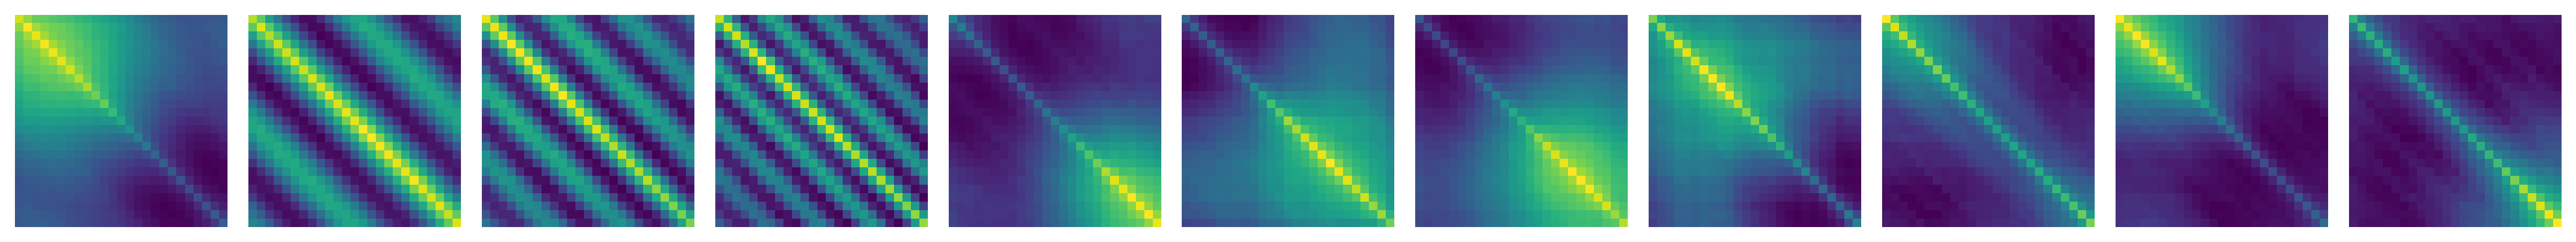

In [388]:
fig, ax = plt.subplots(1, hmm_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(hmm_covs):
    ax[i].imshow(cov, cmap = "viridis")
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/raw_figures/{sim_cond}_hmm_covs.pdf",
    bbox_inches="tight",
    pad_inches=0.05,)


/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_3244/4174802722.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


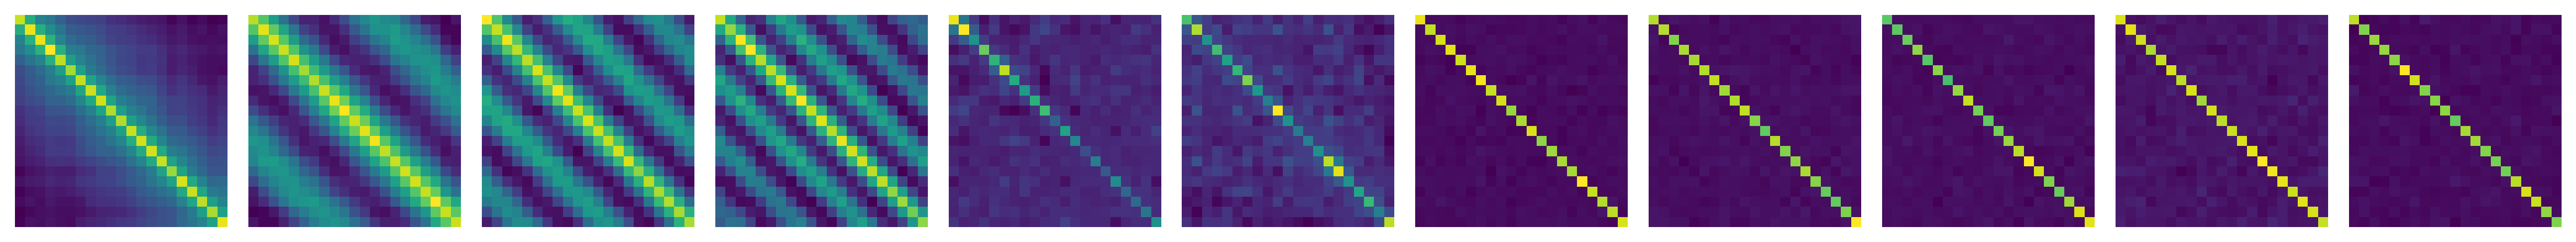

In [390]:

fig, ax = plt.subplots(1, untrunc_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(untrunc_covs):
    ax[i].imshow(cov,  cmap = "viridis")
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/raw_figures/{sim_cond}_dpgmm_covs.pdf",
    bbox_inches="tight",
    pad_inches=0.05,)


## states before imputation


In [44]:
_gmm_mcc = res.query("method == 'DP-GMM'").mcc.values[0]
_gmm_states = res.query("method == 'DP-GMM'").est_states.to_numpy()[0]
_gmm_states_onehot = np.eye(num_states)[_gmm_states]

_hmm_mcc = res.query("method == 'HMM'").mcc.values[0]
_hmm_states = res.query("method == 'HMM'").est_states.to_numpy()[0]
_hmm_states_onehot = np.eye(num_states)[_hmm_states]


print("dp-gmm", _gmm_mcc)
print("dp-gmm (imputed)", gmm_mcc)

print("hmm", _hmm_mcc)
print("hmm (imputed)", hmm_mcc)


"""
dp-gmm 0.8618107993142023
dp-gmm (imputed) 0.938337224764793
hmm 0.3483492480108877
hmm (imputed) 0.3112647340620908
"""

dp-gmm 0.7867980238454724
dp-gmm (imputed) 0.8628597299168914
hmm 0.2948150091081837
hmm (imputed) 0.29531453898890464


'\ndp-gmm 0.8618107993142023\ndp-gmm (imputed) 0.938337224764793\nhmm 0.3483492480108877\nhmm (imputed) 0.3112647340620908\n'

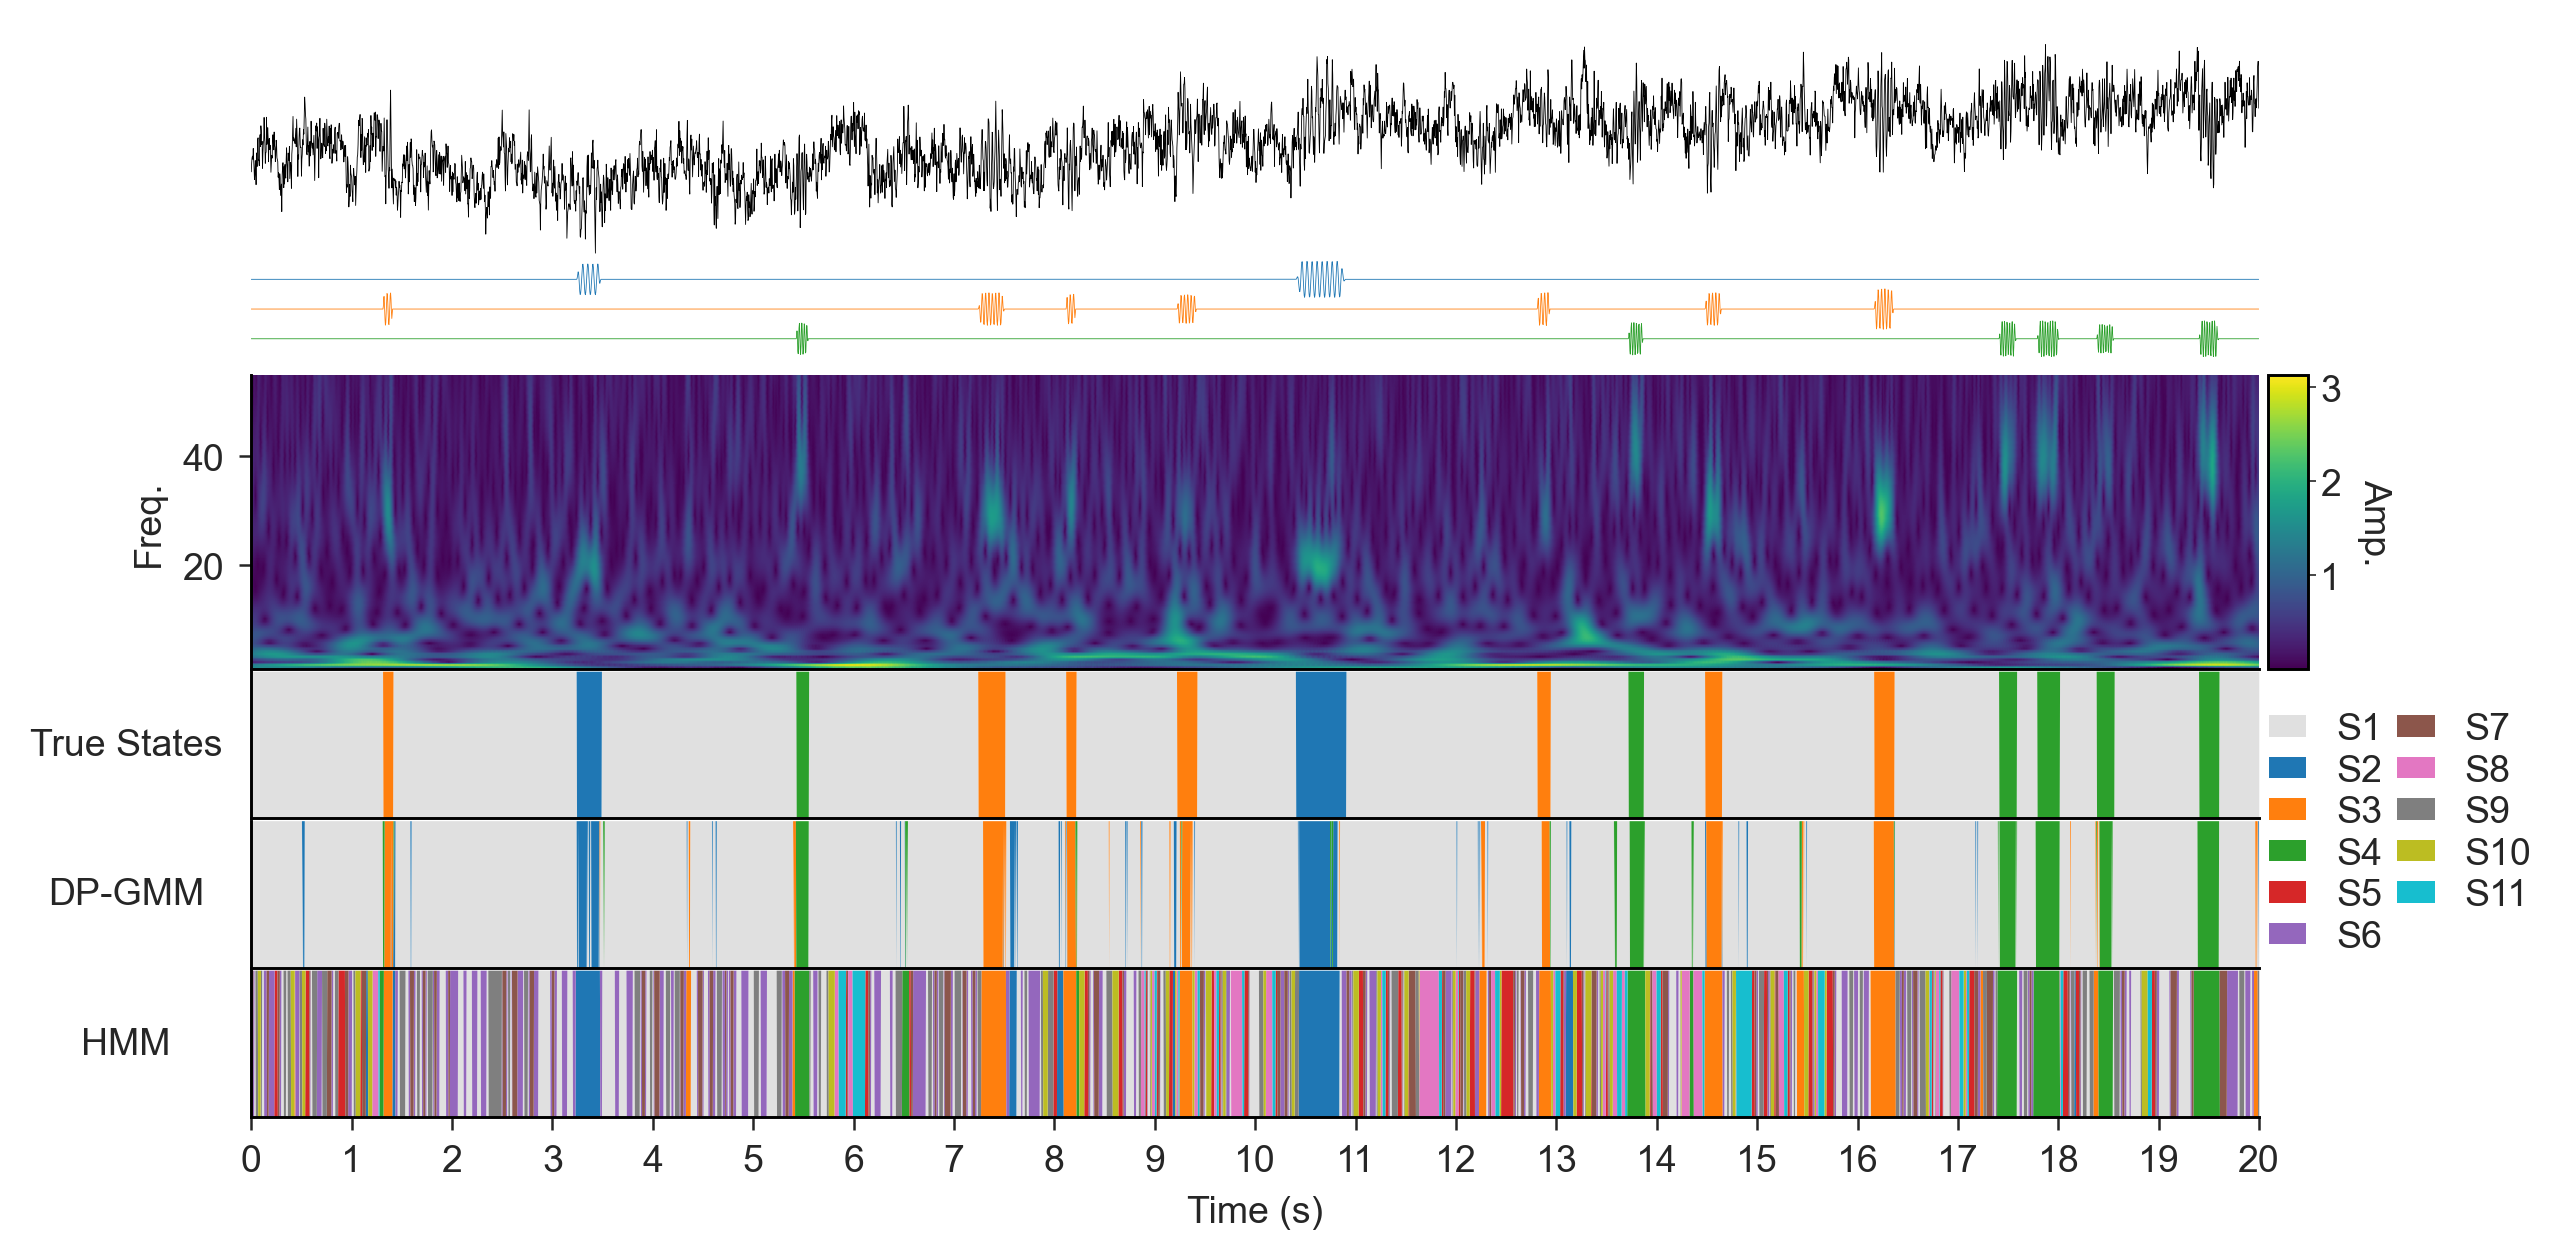

In [45]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3,0.3]}
)

fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)



axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], _gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {_gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], _hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {_hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.33), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )



fig.savefig(
    f"../figures/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


plt.show()



## HMM

In [355]:
import pickle
save_path = os.path.join(performance_dir, f"{sim_cond}_HMM_results.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)

df.head()


,method,signal,true_states,burst_f,fs,snr,est_params,best_model_id,loss_best,loss_all,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.74486524, 0.25513476], 't...",7,0.546423,"[[1.4314460714299742, 1.250953059730719, 1.151...",73.301494,0.523111,73.824605,2,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0]",None,None,0.546423
1,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.62651044, 0.20530105, 0.1...",2,0.539855,"[[1.6324689039241207, 1.2568464254477476, 1.15...",48.039872,0.367093,48.406966,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 2, 1]",None,None,0.539855
2,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.40047932, 0.14736506, 0.2...",0,0.530635,"[[1.4887848861504835, 1.4236964855674614, 1.27...",86.767325,0.171692,86.939017,4,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 1, 3, 0]",None,None,0.530635
3,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.32911584, 0.18618357, 0.1...",4,0.527656,"[[1.4836739567833206, 1.2856269277421006, 1.31...",106.047387,0.188655,106.236042,5,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4, 2, 0, 3, 1]",None,None,0.527656
4,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.20053026, 0.22559878, 0.2...",3,0.518811,"[[1.5965215600881493, 1.1739165587918023, 1.13...",139.007899,0.206383,139.214281,6,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 0, 4, 3, 5, 2]",None,None,0.518811


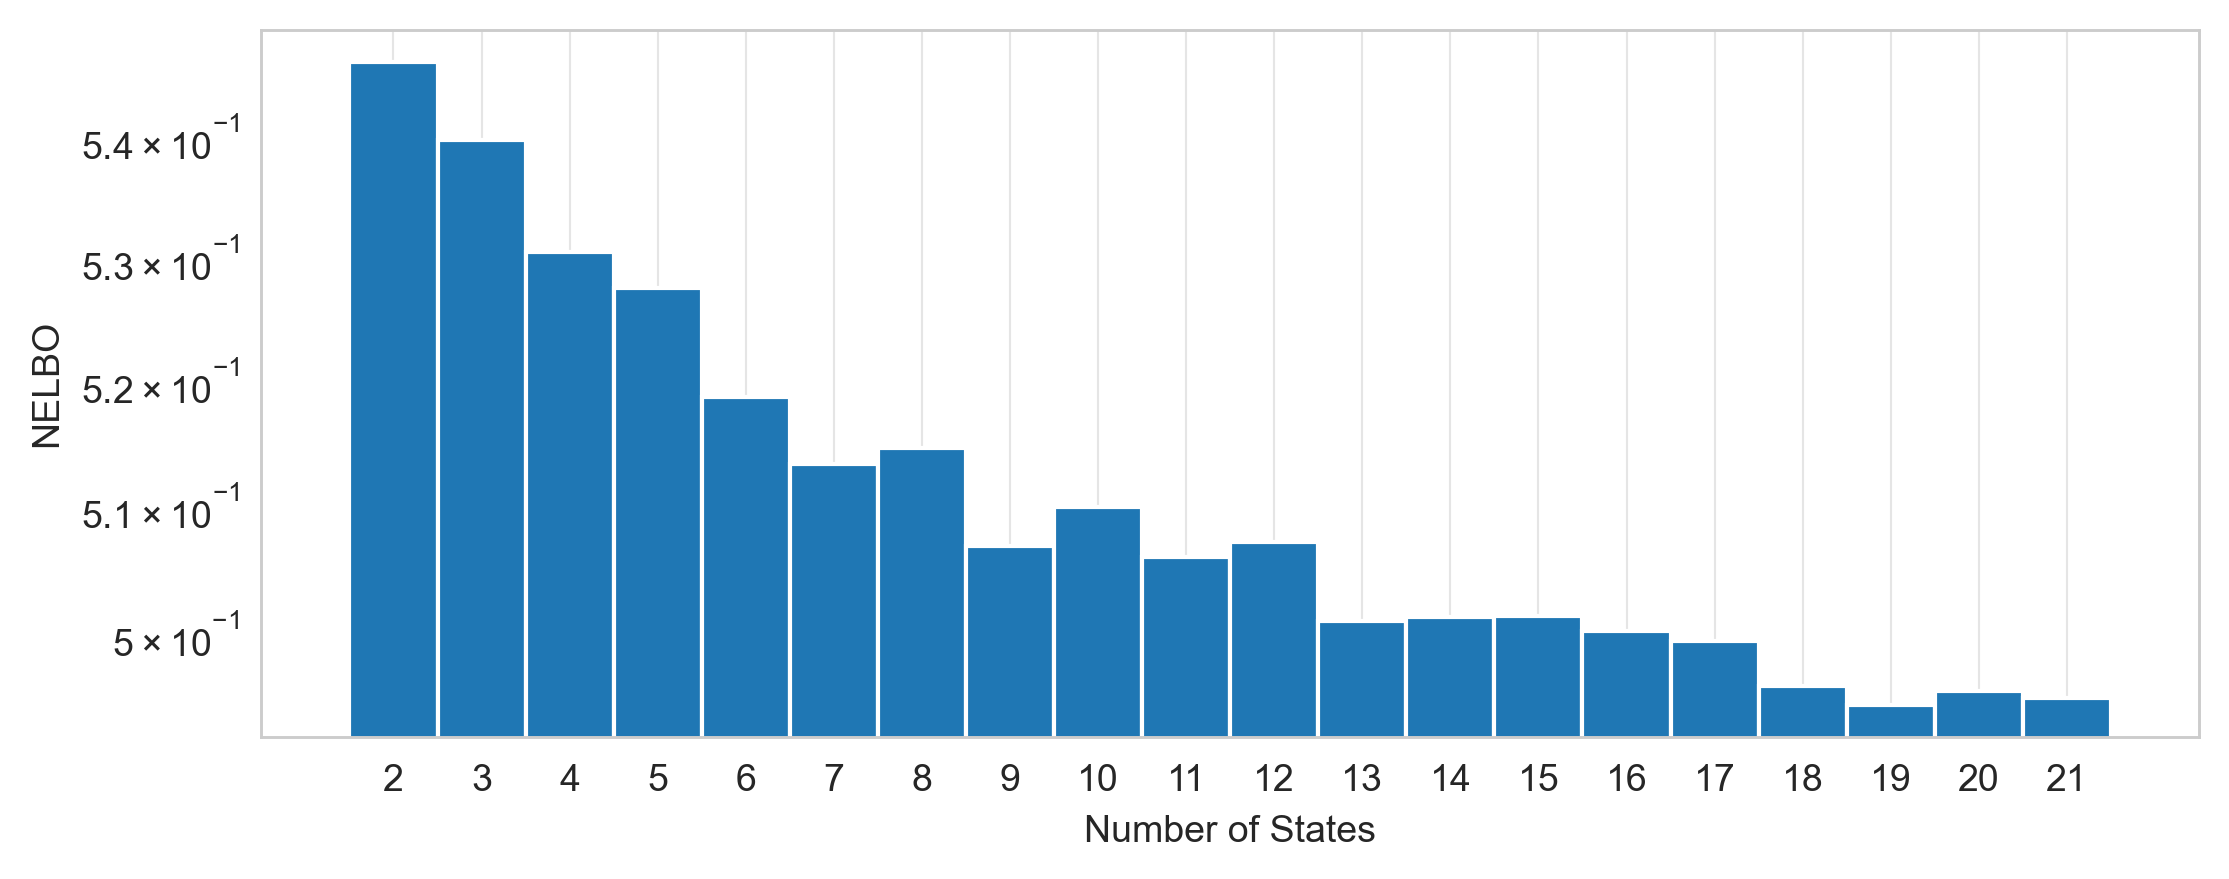

In [47]:
hmm_res = df.query("method == 'HMM'")
num_states_vec = hmm_res.num_states.to_numpy().astype(int)


hmm_color   = "#1f77b4"



elbos = hmm_res["loss_best"]
fig, ax = plt.subplots(figsize = (FIG_WIDTH, 3))
ax.bar(num_states_vec, elbos, color = hmm_color, width = 1, align = "center")
ax.set_yscale("log")
ax.set_xticks(num_states_vec)
ax.set_ylabel("NELBO")
ax.set_xlabel("Number of States")


fig.savefig(
    f"../figures/{sim_cond}_HMM_nelbo.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)






